# Workout Model

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

## Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Atur style agar grafik terlihat modern
sns.set_theme(style="whitegrid")

# Load Dataset (Pastikan nama filenya sesuai dengan punyamu)
df = pd.read_csv('../.././data/dataset_workout_final.csv')

# Membuat dataframe khusus untuk analisis Profil (mengambil 1 baris per User_ID)
# Ini TIDAK menghapus data asli df, hanya membuat tampilan/filter baru
df_users = df.drop_duplicates(subset=['User_ID'])

print(f"Total baris di dataset utuh: {len(df)}")
print(f"Total User Unik untuk dianalisis: {len(df_users)}")
print("Total Kolom:", len(df.columns))

Total baris di dataset utuh: 12451
Total User Unik untuk dianalisis: 700
Total Kolom: 43


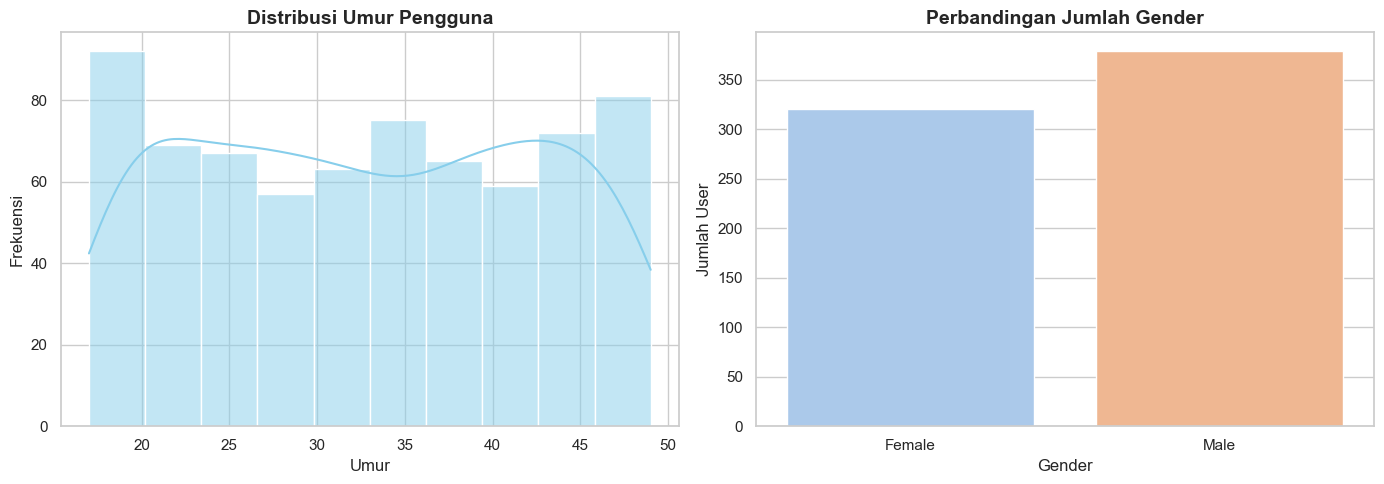

In [3]:
plt.figure(figsize=(14, 5))

# Grafik 1: Histogram Umur
plt.subplot(1, 2, 1)
sns.histplot(data=df_users, x='Age_x', bins=10, kde=True, color='skyblue')
plt.title('Distribusi Umur Pengguna', fontsize=14, fontweight='bold')
plt.xlabel('Umur')
plt.ylabel('Frekuensi')

# Grafik 2: Perbandingan Gender
plt.subplot(1, 2, 2)
sns.countplot(data=df_users, x='Gender_x', hue='Gender_x', palette='pastel', legend=False)
plt.title('Perbandingan Jumlah Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Jumlah User')

plt.tight_layout()
plt.show()

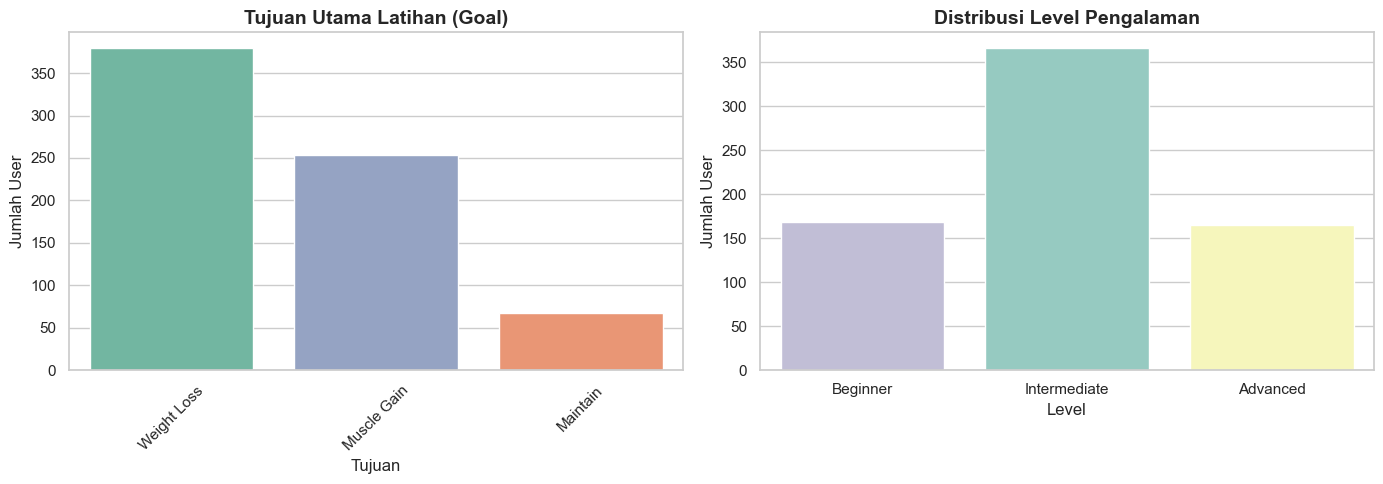

In [4]:
plt.figure(figsize=(14, 5))

# Grafik 3: Tujuan Diet/Latihan (Goal)
plt.subplot(1, 2, 1)
sns.countplot(data=df_users, x='Goal_x', hue='Goal_x', palette='Set2', legend=False, order=df_users['Goal_x'].value_counts().index)
plt.title('Tujuan Utama Latihan (Goal)', fontsize=14, fontweight='bold')
plt.xlabel('Tujuan')
plt.ylabel('Jumlah User')
plt.xticks(rotation=45)

# Grafik 4: Level Pengalaman
plt.subplot(1, 2, 2)
sns.countplot(data=df_users, x='level_x', hue='level_x', palette='Set3', legend=False, order=['Beginner', 'Intermediate', 'Advanced'])
plt.title('Distribusi Level Pengalaman', fontsize=14, fontweight='bold')
plt.xlabel('Level')
plt.ylabel('Jumlah User')

plt.tight_layout()
plt.show()

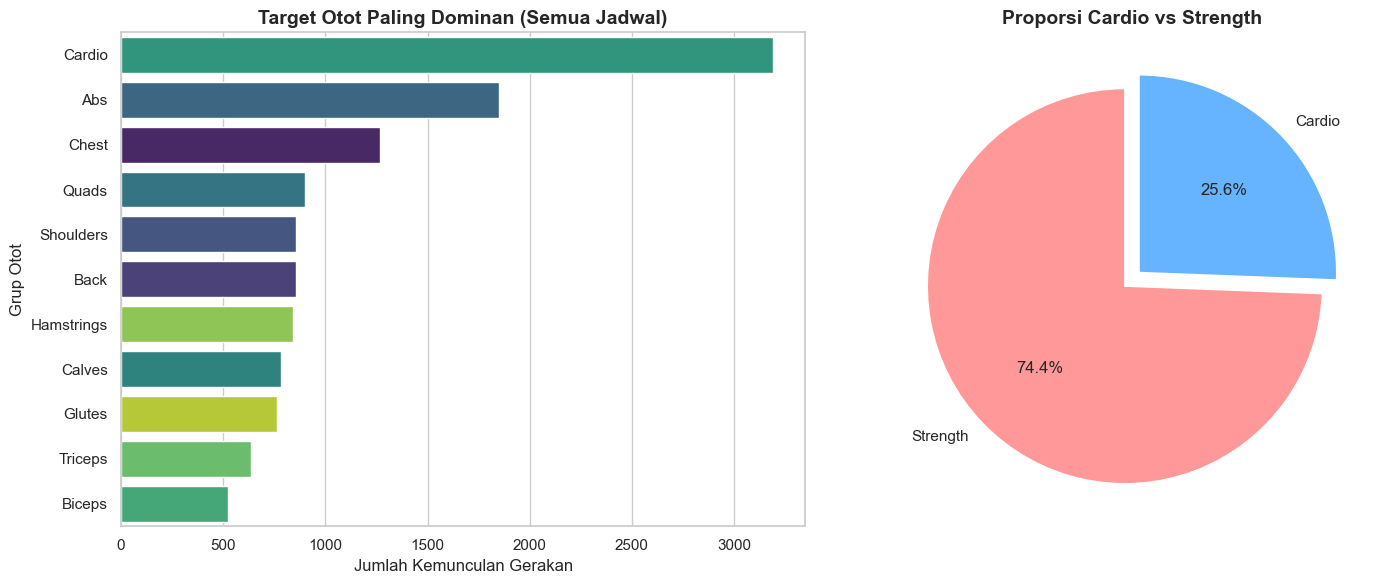

In [5]:
plt.figure(figsize=(15, 6))

# Grafik 5: Grup Otot yang Paling Sering Dilatih
plt.subplot(1, 2, 1)
order_muscle = df['Muscle Group'].value_counts().index
sns.countplot(data=df, y='Muscle Group', hue='Muscle Group', order=order_muscle, palette='viridis', legend=False)
plt.title('Target Otot Paling Dominan (Semua Jadwal)', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Kemunculan Gerakan')
plt.ylabel('Grup Otot')

# Grafik 6: Tipe Latihan (Pie chart tidak perlu diubah, aman!)
plt.subplot(1, 2, 2)
type_counts = df['Workout_Type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', 
        colors=['#ff9999','#66b3ff'], startangle=90, explode=[0.05]*len(type_counts))
plt.title('Proporsi Cardio vs Strength', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

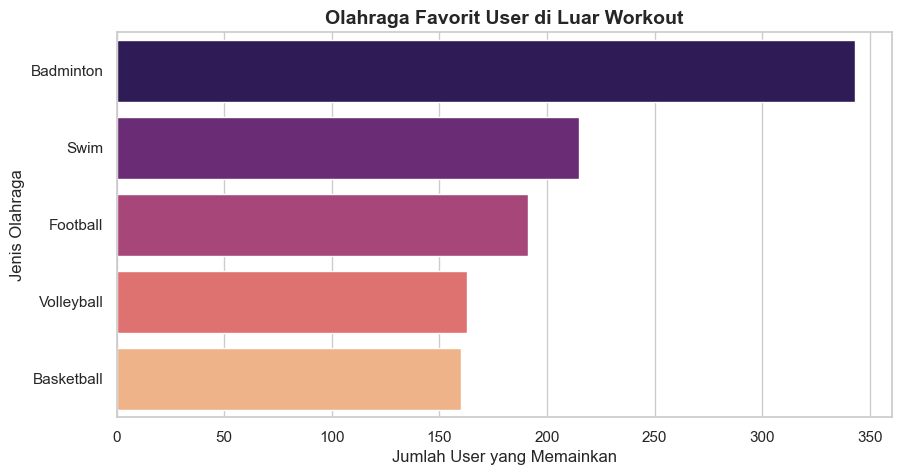

In [6]:
# Mengambil kolom-kolom hobi
sports_cols = ['Badminton', 'Football', 'Basketball', 'Volleyball', 'Swim']

# Menghitung total angka '1' di masing-masing kolom hobi
sports_counts = df_users[sports_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=sports_counts.values, y=sports_counts.index, hue=sports_counts.index, palette='magma', legend=False)
plt.title('Olahraga Favorit User di Luar Workout', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah User yang Memainkan')
plt.ylabel('Jenis Olahraga')
plt.show()

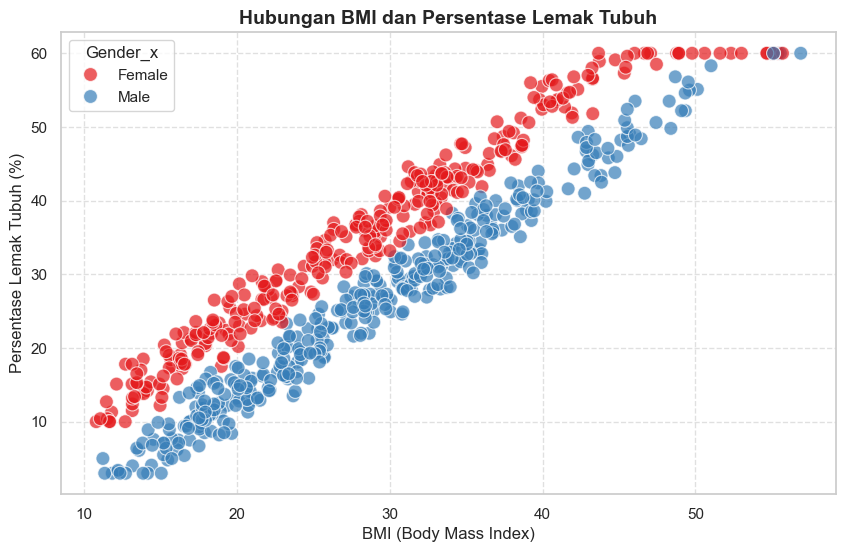

In [7]:
plt.figure(figsize=(10, 6))
# Scatter plot BMI vs Body Fat, diwarnai berdasarkan Gender
sns.scatterplot(data=df_users, x='Initial_BMI_x', y='Body_Fat_Percentage_x', 
                hue='Gender_x', palette='Set1', s=100, alpha=0.7)

plt.title('Hubungan BMI dan Persentase Lemak Tubuh', fontsize=14, fontweight='bold')
plt.xlabel('BMI (Body Mass Index)')
plt.ylabel('Persentase Lemak Tubuh (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Global Configuration

In [8]:
# Define a specific number (Seed) to ensure the code behaves exactly the same way
# every time we run it. This prevents random changes in model scores.
SEED = 26

# Lock the random number generator of NumPy using our Seed.
np.random.seed(SEED)

# Configure Pandas to display ALL columns when printing a dataframe.
# By default, Pandas hides middle columns with "..." if there are too many.
# We disable this limit so we can inspect all our features during debugging.
pd.set_option('display.max_columns', None)

## Preprocessing Data

### Load Data

In [9]:
# Load the CSV file
# This dataset contains the list of exercises (Pushups, Squats, etc.)
# and their attributes (Difficulty, Muscle Group, Equipment).
df_final = pd.read_csv('../../data/dataset_workout_final.csv')

# Clean Column Names
# Just like with meals, we strip spaces to avoid "KeyError" later.
df_final.columns = df_final.columns.str.strip()

# Verification
print(f"Data Loaded: {df_final.shape[0]} rows, {df_final.shape[1]} columns.")

Data Loaded: 12451 rows, 43 columns.


In [10]:
# The function tells us:
# 1. How many rows and columns we have.
# 2. The Name and Data Type (Dtype) of each column (int, float, object/text).
# 3. "Non-Null Count": If this number is lower than the total rows, we have missing data!
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12451 entries, 0 to 12450
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     12451 non-null  int64  
 1   Age_x                       12451 non-null  int64  
 2   Gender_x                    12451 non-null  object 
 3   Height_cm_x                 12451 non-null  int64  
 4   Initial_Weight_kg_x         12451 non-null  int64  
 5   Initial_BMI_x               12451 non-null  float64
 6   BMI_Category_x              12420 non-null  object 
 7   Body_Fat_Category_x         12451 non-null  float64
 8   Body_Fat_Percentage_x       12451 non-null  float64
 9   Goal_x                      12451 non-null  object 
 10  Workout_Frequency_x         12451 non-null  int64  
 11  Average_Duration_Minutes_x  12451 non-null  int64  
 12  level_x                     12451 non-null  object 
 13  Badminton                   124

### Encode Data

In [11]:
# Isolate Unique Users
# Cardio columns
cardio_cols = ["Badminton", "Football", "Basketball", "Volleyball", "Swim"]

# We want just ONE row per user to build their "Profile".
cols_profile = ['User_ID', 'Age_x', 'Gender_x', 'Initial_Weight_kg_x', 'Goal_x', 'Workout_Frequency_x', 'level_x', 'Environment'] + cardio_cols
df_profiles = df_final[cols_profile].drop_duplicates().reset_index(drop=True)

# Encode Categorical Data (Text -> Numbers)
# We initialize encoders for Gender, Goal, and Level.
le_gender = LabelEncoder()
le_goal = LabelEncoder()
le_level = LabelEncoder()
le_environment = LabelEncoder()

df_profiles['Gender_Encoded'] = le_gender.fit_transform(df_profiles['Gender_x'])
df_profiles['Goal_Encoded'] = le_goal.fit_transform(df_profiles['Goal_x'])
df_profiles['level_Encoded'] = le_level.fit_transform(df_profiles['level_x'])
df_profiles['environment_Encoded'] = le_environment.fit_transform(df_profiles['Environment'])


# Define Features for Similarity Search
features_knn = ['Goal_Encoded', 'Workout_Frequency_x', 'level_Encoded', 'Gender_Encoded', 'Age_x', 'Initial_Weight_kg_x', 'environment_Encoded'] + cardio_cols

### Splitting & Scaling Data

In [12]:
# Split the data
# We split the profiles into a "Database" (Train) and "New Users" (Test)
train_df, test_df = train_test_split(
    df_profiles, test_size=0.3, random_state=SEED
)

# Initialize Scaler & Encode
# We fit the scaler ONLY on the "Database" (Train)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(train_df[features_knn])

# We transform the "New Users" (Test) using the Database's rules
X_test = scaler.transform(test_df[features_knn])

### Weighting Data

In [13]:
# We convert numpy arrays to DataFrames temporarily to make multiplication easy
X_train_df = pd.DataFrame(X_train, columns=features_knn)
X_test_df = pd.DataFrame(X_test, columns=features_knn)

# Define the weight
weights = {
    'Goal_Encoded': 65,          
    'level_Encoded': 53,         
    'Workout_Frequency_x': 180,   
    'environment_Encoded': 50,   
    'Gender_Encoded': 3,
    'Age_x': 5,                  
    'Initial_Weight_kg_x': 10,
    'Badminton': 31, 
    'Football': 31, 
    'Basketball': 31, 
    'Volleyball': 30,
    'Swim': 32    
}

for col, weight in weights.items():
    # Multiply the column by the weight
    X_train_df[col] = X_train_df[col] * weight
    X_test_df[col] = X_test_df[col] * weight

# Convert back to values for KNN
X_train_weighted = X_train_df.values
X_test_weighted = X_test_df.values

## Modelling

### Model

In [14]:
# Train KNN on the Database
knn = NearestNeighbors(n_neighbors=1, metric='euclidean')
knn.fit(X_train_weighted)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


### Evaluation

In [15]:
print("Calculating Metric Evaluation...")
distances, indices = knn.kneighbors(X_test_weighted)
eval_data = []

# Evaluation Loop
count = len(test_df)
for i in range(count):
    # A. The "Target" (New User)
    user = test_df.iloc[i]
    
    # B. The "Recommendation" (Existing User)
    idx_teman_rekomendasi = indices[i][0]
    teman = train_df.iloc[idx_teman_rekomendasi]
    
    # C. Standard Checks (The Basics)
    entry = {
        'User_ID': user['User_ID'],
        'User_Goal': user['Goal_x'], # Added for grouping later
        'Sama_Goal': (user['Goal_x'] == teman['Goal_x']),
        'Sama_Level': (user['level_x'] == teman['level_x']),
        'Sama_Freq': (user['Workout_Frequency_x'] == teman['Workout_Frequency_x']),
        'Sama_Gender': (user['Gender_x'] == teman['Gender_x']),
        'Sama_Environment': (user['Environment'] == teman['Environment']),
        'Selisih_Berat': abs(user['Initial_Weight_kg_x'] - teman['Initial_Weight_kg_x']),
        'Selisih_Umur': abs(user['Age_x'] - teman['Age_x'])
    }
    
    # D. Cardio Checks (The New Logic)
    # We loop through each sport to see if the capability matches (1 vs 1 OR 0 vs 0)
    for sport in cardio_cols:
        is_same = (user[sport] == teman[sport])
        
        # Clean the name for the report (e.g., "Badminton_x" -> "Sama_Badminton")
        clean_name = f"Sama_{sport.replace('_x', '')}"
        entry[clean_name] = is_same
        
    eval_data.append(entry)

df_eval = pd.DataFrame(eval_data)

print("\n" + "="*40)
print("     RECOMMENDATION MODEL")
print("="*40)

# [A] CORE METRICS
print(f"\n[A] CORE ACCURACY")
print(f"1. Same Goal       : {(df_eval['Sama_Goal'].mean() * 100):.2f}%")
print(f"2. Same Level      : {(df_eval['Sama_Level'].mean() * 100):.2f}%")
print(f"3. Same Frequency  : {(df_eval['Sama_Freq'].mean() * 100):.2f}%")
print(f"4. Same Environment: {(df_eval['Sama_Environment'].mean() * 100):.2f}%")

# [B] CARDIO METRICS (Dynamic Loop)
print(f"\n[B] CARDIO COMPATIBILITY")
for sport in cardio_cols:
    clean_name = f"Sama_{sport.replace('_x', '')}"
    score = df_eval[clean_name].mean() * 100
    # Formatting text to line up nicely
    print(f"{clean_name.replace('Sama_', '').ljust(15)} Match : {score:.2f}%")

# [C] PHYSICAL METRICS
print(f"\n[C] AVERAGE DEVIATION")
print(f"1. Age Diff        : Avg {df_eval['Selisih_Umur'].mean():.2f} years")
print(f"2. Weight Diff     : Avg {df_eval['Selisih_Berat'].mean():.2f} kg")

# [D] WORST CASE
print(f"\n[D] WORST 3 MATCHES (By Weight Diff)")
worst_cases = df_eval.sort_values('Selisih_Berat', ascending=False).head(3)
# Show relevant columns for debugging
cols_to_show = ['User_Goal', 'Selisih_Berat', 'Sama_Freq'] + [f"Sama_{cardio_cols[0].replace('_x','')}" ]
print(worst_cases[cols_to_show].to_string(index=False))

print("\n" + "="*40)

Calculating Metric Evaluation...



     RECOMMENDATION MODEL

[A] CORE ACCURACY
1. Same Goal       : 94.76%
2. Same Level      : 85.24%
3. Same Frequency  : 100.00%
4. Same Environment: 100.00%

[B] CARDIO COMPATIBILITY
Badminton       Match : 92.86%
Football        Match : 92.38%
Basketball      Match : 93.33%
Volleyball      Match : 90.00%
Swim            Match : 94.76%

[C] AVERAGE DEVIATION
1. Age Diff        : Avg 8.31 years
2. Weight Diff     : Avg 15.66 kg

[D] WORST 3 MATCHES (By Weight Diff)
  User_Goal  Selisih_Berat  Sama_Freq  Sama_Badminton
Weight Loss             71       True            True
Muscle Gain             59       True            True
Weight Loss             53       True            True



### Model Dump

In [16]:
print("Training Final Model on 100% Data...")

# Scale 100% of the User Data
# We create a NEW scaler and fit it on the entire 'df_profiles'.
# This ensures the scaler knows the min/max of ALL your users.
scaler_final = MinMaxScaler()
features_raw = scaler_final.fit_transform(df_profiles[features_knn])

# We must multiply the training data by the weights so the model learns the "Rules"
df_weighted_final = pd.DataFrame(features_raw, columns=features_knn)

for col, weight in weights.items():
    if col in df_weighted_final.columns:
        df_weighted_final[col] = df_weighted_final[col] * weight

features_final_ready = df_weighted_final.values

# Train the Matchmaker on 100% Data
# Now we train a NEW KNN model on that complete dataset.
knn_final = NearestNeighbors(n_neighbors=1, metric='euclidean')
knn_final.fit(features_final_ready)

# Package Everything
# We bundle all the tools your App needs into one dictionary.
data_workout_model = {
    'knn_model': knn_final,         # The Brain (Trained on 100% data)
    'scaler': scaler_final,         # The Tool to scale new user inputs
    'profiles_db': df_profiles,     # The Phonebook (To look up User IDs)
    'schedule_db': df_final,        # The Workout Logs (To see what they did)
    'weights': weights,
    'encoders': {                   # The Translators (Text -> Numbers)
        'gender': le_gender,
        'goal': le_goal,
        'level': le_level,
        'environment': le_environment
    },
    'features': features_knn        # The Map (Order of inputs)
}

# Save to File
save_path = '../../models/model_workout.pickle'

with open(save_path, 'wb') as f:
    pickle.dump(data_workout_model, f)

print(f"\nSUCCESS: 'model_workout.pickle' saved to {save_path}")

Training Final Model on 100% Data...

SUCCESS: 'model_workout.pickle' saved to ../../models/model_workout.pickle
